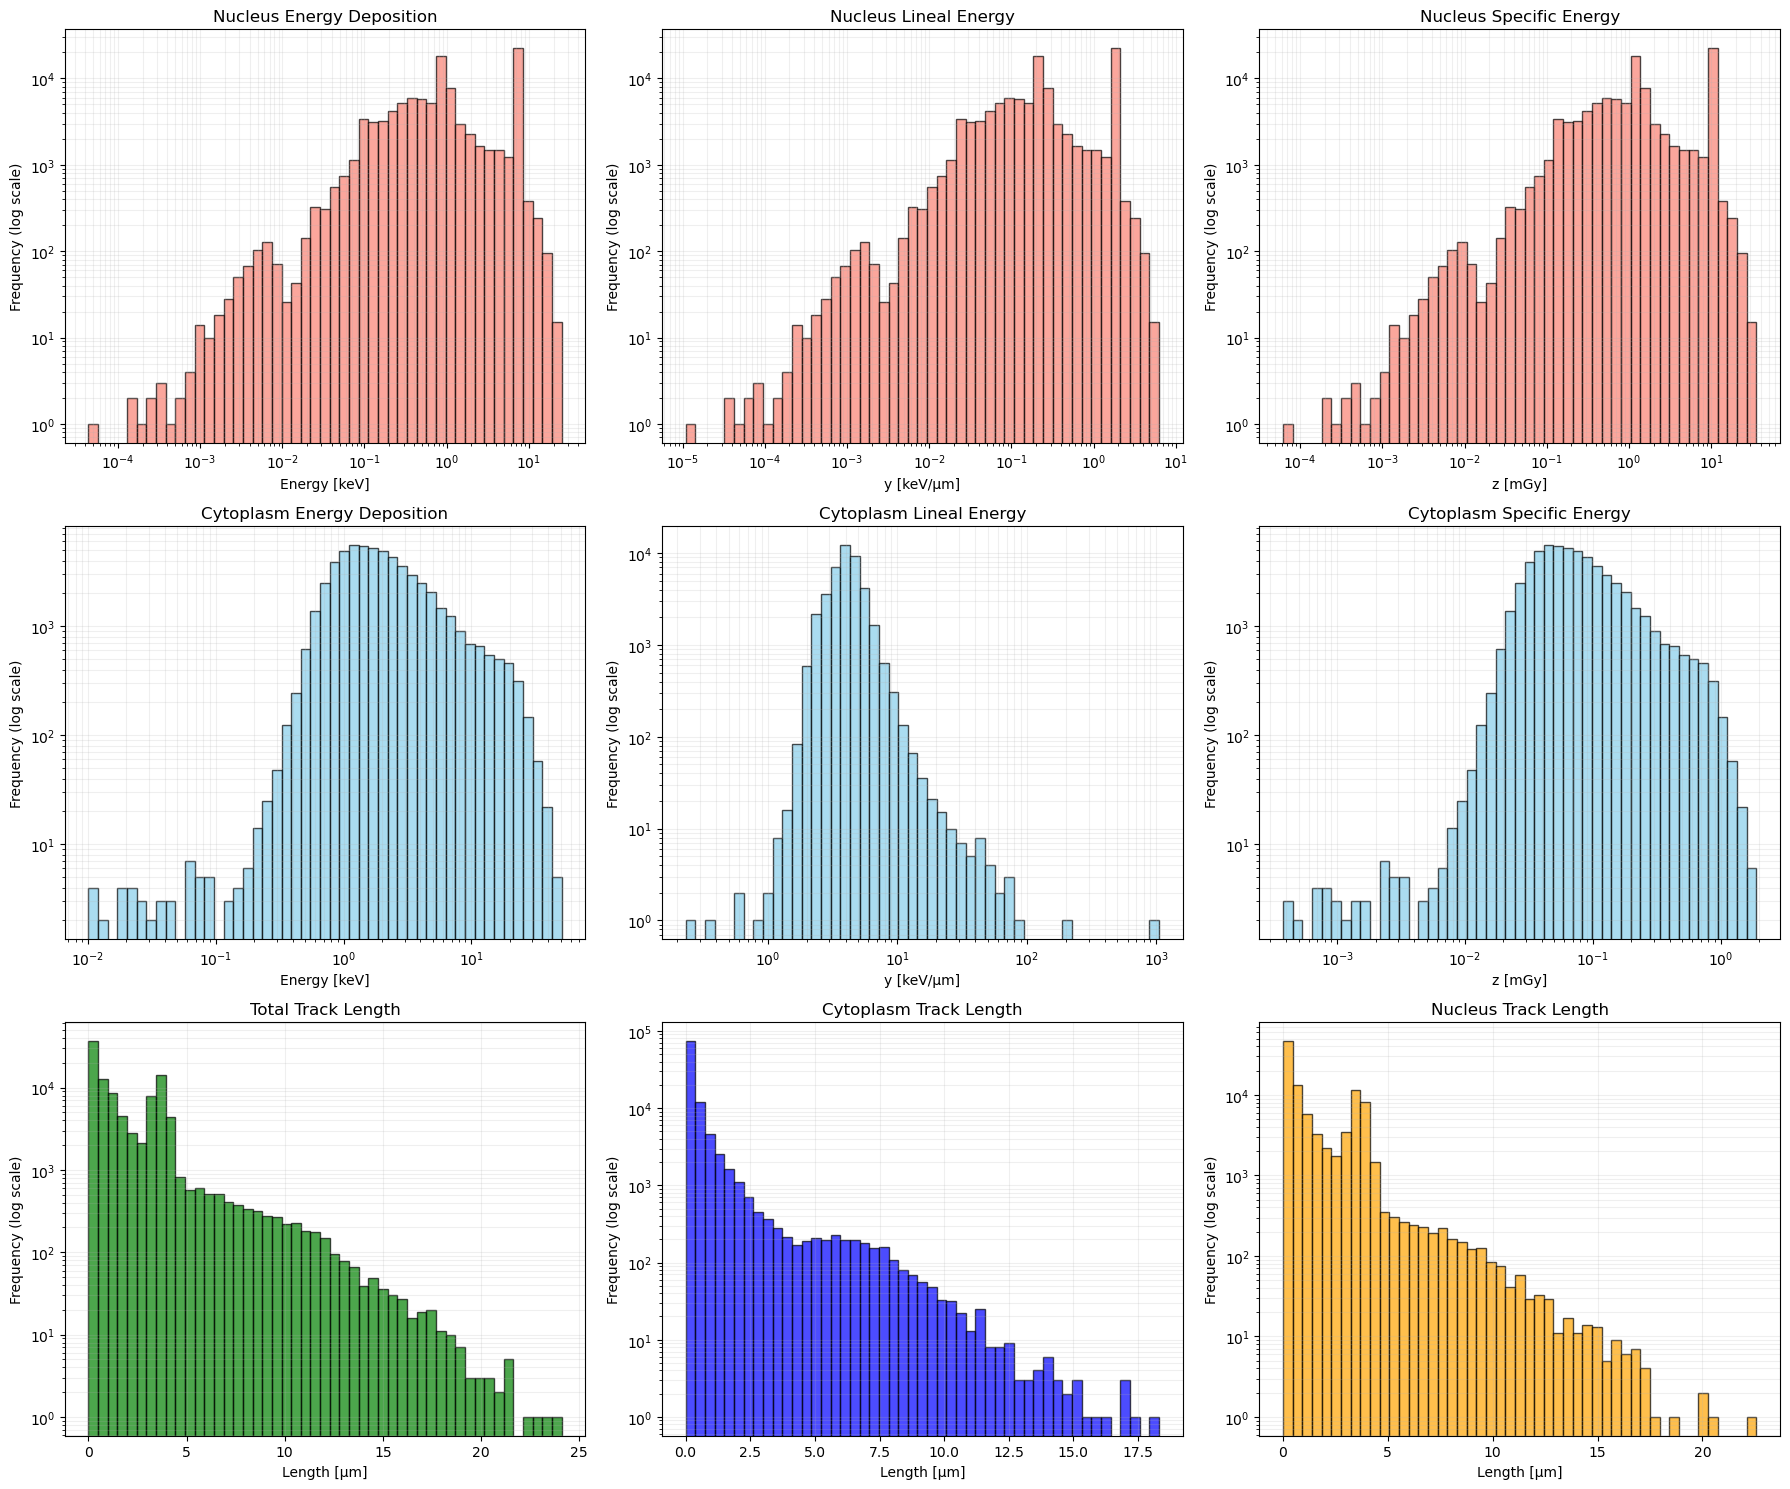

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Caricamento
nomi_colonne = ["EdepNuc_keV", "yNuc_keV_um", "zNuc_mGy", "EdepCyto_keV", "yCyto_keV_um", "zCyto_mGy", "TotalTrackLength_um", "CytoTrackLength_um"]
df = pd.read_csv('output/microdosimetria_nt_Micro.csv', comment='#', names=nomi_colonne, sep=',')

# 2. Pre-elaborazione Dati (FONDAMENTALE)
df['NucTrackLength_um'] = df['TotalTrackLength_um'] - df['CytoTrackLength_um']

# Pulizia yCyto: gestiamo gli infiniti/zero prima di plottare
# Usiamo una soglia minima per la lunghezza del track per evitare la divisione per zero
eps = 1e-9 
mask = df['CytoTrackLength_um'] > eps
df.loc[mask, 'yCyto_keV_um'] = df.loc[mask, 'EdepCyto_keV'] / df.loc[mask, 'CytoTrackLength_um']
df.loc[~mask, 'yCyto_keV_um'] = np.nan  # Mettiamo NaN dove non è calcolabile

# 3. Configurazione Grafici
# (Colonna, Titolo, Label X, Colore, 'log' o 'linear' per l'asse X)
plot_configs = [
    ('EdepNuc_keV', 'Nucleus Energy Deposition', 'Energy [keV]', 'salmon', 'log'),
    ('yNuc_keV_um', 'Nucleus Lineal Energy', 'y [keV/µm]', 'salmon', 'log'),
    ('zNuc_mGy', 'Nucleus Specific Energy', 'z [mGy]', 'salmon', 'log'),
    ('EdepCyto_keV', 'Cytoplasm Energy Deposition', 'Energy [keV]', 'skyblue', 'log'),
    ('yCyto_keV_um', 'Cytoplasm Lineal Energy', 'y [keV/µm]', 'skyblue', 'log'),
    ('zCyto_mGy', 'Cytoplasm Specific Energy', 'z [mGy]', 'skyblue', 'log'),
    ('TotalTrackLength_um', 'Total Track Length', 'Length [µm]', 'green', 'linear'),
    ('CytoTrackLength_um', 'Cytoplasm Track Length', 'Length [µm]', 'blue', 'linear'),
    ('NucTrackLength_um', 'Nucleus Track Length', 'Length [µm]', 'orange', 'linear')
]

# 4. Generazione Plot
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (col, title, xlabel, color, scale) in enumerate(plot_configs):
    ax = axes[i]
    data = df[col].dropna()
    
    if data.empty:
        ax.text(0.5, 0.5, 'Dati mancanti', ha='center', va='center')
        continue

    # Scelta dei Bins intelligenti
    if scale == 'log':
        # Filtriamo solo valori > 0 per la scala log
        data_pos = data[data > 0]
        bins = np.logspace(np.log10(data_pos.min()), np.log10(data_pos.max()), 50)
        ax.set_xscale('log')
    else:
        bins = np.linspace(data.min(), data.max(), 50)
        ax.set_xscale('linear')

    ax.hist(data, bins=bins, color=color, alpha=0.7, edgecolor='black')
    ax.set_yscale('log') # Manteniamo la scala logaritmica sull'asse Y per le frequenze
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency (log scale)')
    ax.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()


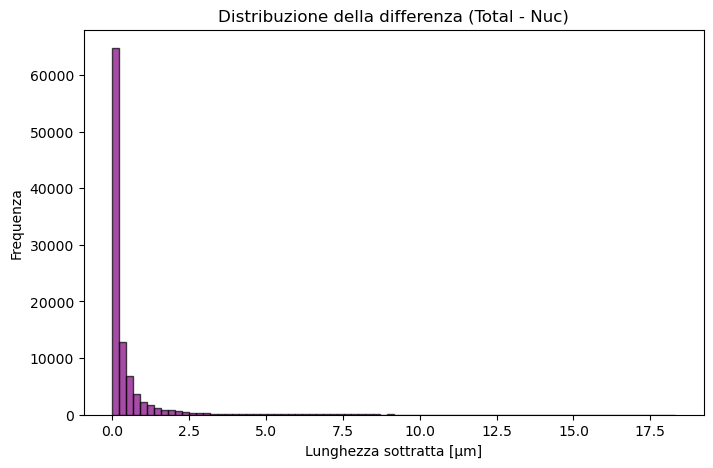

In [2]:
# Distribuzione di residuo fra TotalTrackLength_um e NucTrackLength_um
diff = df['TotalTrackLength_um'] - df['NucTrackLength_um'] # Questo è CytoTrackLength!

plt.figure(figsize=(8, 5))
plt.hist(diff, bins=80, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribuzione della differenza (Total - Nuc)')
plt.xlabel('Lunghezza sottratta [µm]')
plt.ylabel('Frequenza')
plt.show()

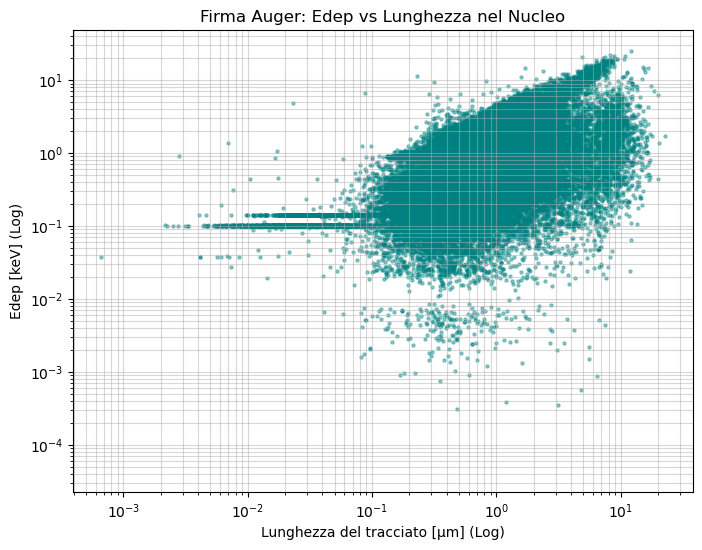

In [3]:
plt.figure(figsize=(8, 6))
# Usiamo solo i casi in cui l'energia depositata è > 0 per evitare log(0)
mask = df['EdepNuc_keV'] > 0
plt.scatter(df.loc[mask, 'NucTrackLength_um'], df.loc[mask, 'EdepNuc_keV'], 
            alpha=0.4, s=5, c='teal')
plt.xscale('log')
plt.yscale('log')
plt.title('Firma Auger: Edep vs Lunghezza nel Nucleo')
plt.xlabel('Lunghezza del tracciato [µm] (Log)')
plt.ylabel('Edep [keV] (Log)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

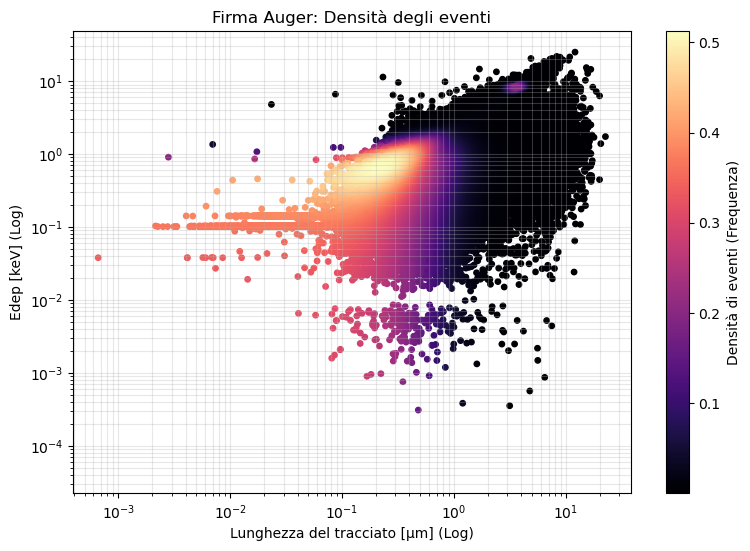

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. Definiamo i dati
x = df['NucTrackLength_um']
y = df['EdepNuc_keV']

# 2. Calcoliamo la densità dei punti (Kernel Density Estimation)
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 3. Ordiniamo i punti per densità (così quelli più densi stanno "sopra")
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

# 4. Creiamo lo scatter plot colorato per densità
plt.figure(figsize=(9, 6))
sc = plt.scatter(x, y, c=z, s=15, cmap='magma') # 'inferno' è ottimo per vedere il 'caldo'
plt.colorbar(sc, label='Densità di eventi (Frequenza)')

plt.xscale('log')
plt.yscale('log')
plt.title('Firma Auger: Densità degli eventi per NucTrackLength')
plt.xlabel('Lunghezza del tracciato [µm] (Log)')
plt.ylabel('Edep [keV] (Log)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

# Cioè abbiamo dato vita ad un grafico che mostra non solo la distribuzione dei punti, ma anche la loro densità, evidenziando le regioni in cui gli eventi sono più frequenti. Questo l'abbiamo fatto usando una tecnica chiamata Kernel Density Estimation (KDE) per stimare la densità dei punti nello spazio (x, y) e colorando i punti in base a questa densità. In questo modo, possiamo facilmente identificare le aree del grafico dove gli eventi sono più concentrati, il che è particolarmente utile quando si lavora con dati logaritmici e distribuzioni ampie come nel caso della firma Auger.

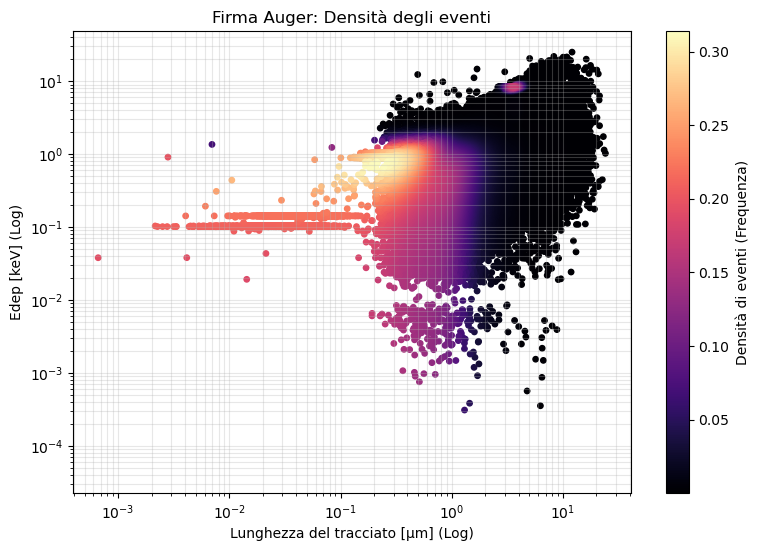

In [ ]:
# 1. Facciamo la stessa cosa per il tracciato totale
x = df['TotalTrackLength_um']
y = df['EdepNuc_keV']

# 2. Calcoliamo la densità dei punti (Kernel Density Estimation)
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 3. Ordiniamo i punti per densità (così quelli più densi stanno "sopra")
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

# 4. Creiamo lo scatter plot colorato per densità
plt.figure(figsize=(9, 6))
sc = plt.scatter(x, y, c=z, s=15, cmap='magma') # 'inferno' è ottimo per vedere il 'caldo'
plt.colorbar(sc, label='Densità di eventi (Frequenza)')

plt.xscale('log')
plt.yscale('log')
plt.title('Firma Auger: Densità degli eventi per TotalTrackLength')
plt.xlabel('Lunghezza del tracciato [µm] (Log)')
plt.ylabel('Edep [keV] (Log)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

# Perché l'heat scatter plot è la firma degli elettroni Auger?

Le linee orizzontali ben visibili nella regione a basso range (a sinistra) confermano che la sorgente Auger sta producendo elettroni con energie discrete e che il mio modello di trasporto sta correttamente simulando il confinamento energetico totale nel nucleo.

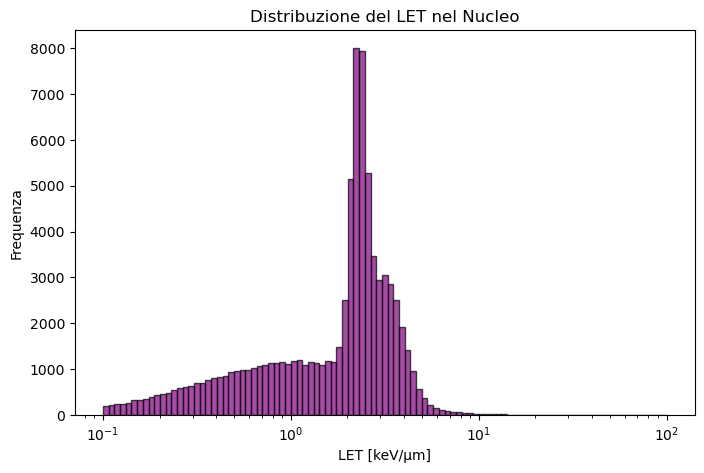

In [5]:
# Calcoliamo il LET approssimato (keV/µm)
df['LET_Nuc'] = df['EdepNuc_keV'] / df['NucTrackLength_um']

# Visualizziamo la distribuzione del LET
plt.figure(figsize=(8, 5))
plt.hist(df['LET_Nuc'][df['LET_Nuc'] > 0], bins=np.logspace(-1, 2, 100), color='purple', alpha=0.7, edgecolor='black')
plt.xscale('log')
plt.title('Distribuzione del LET nel Nucleo')
plt.xlabel('LET [keV/µm]')
plt.ylabel('Frequenza')
plt.show()

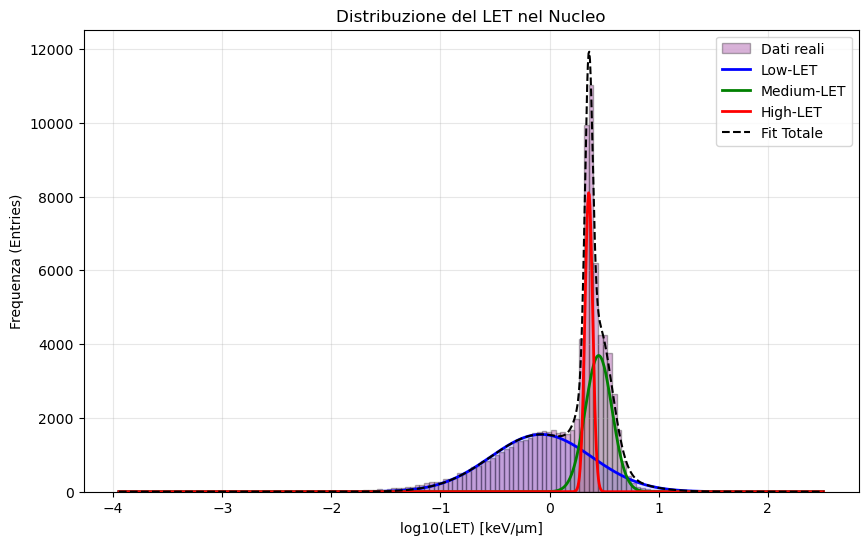

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# 1. SETUP DATI (Assicurati che df sia il tuo dataframe caricato)
# Se 'df' non è definito, carica il tuo file qui, es: df = pd.read_csv('tuo_file.csv')
df_clean = df[(df['NucTrackLength_um'] > 1e-6) & (df['EdepNuc_keV'] > 0)].copy()
df_clean['LET_Nuc_calc'] = df_clean['EdepNuc_keV'] / df_clean['NucTrackLength_um']
mask_finite = np.isfinite(df_clean['LET_Nuc_calc'])
data_to_fit = df_clean.loc[mask_finite, 'LET_Nuc_calc'].values
log_let = np.log10(data_to_fit)

# 2. DEFINIZIONE VARIABILI DI CALCOLO
bins = 150
N_total = len(log_let)
bin_width = (np.max(log_let) - np.min(log_let)) / bins 

# 3. SETUP ISTOGRAMMA
hist, bin_edges = np.histogram(log_let, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 4. MODELLO E FIT
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

def triple_gaussian(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3):
    return gaussian(x, a1, mu1, sigma1) + \
           gaussian(x, a2, mu2, sigma2) + \
           gaussian(x, a3, mu3, sigma3)

# Parametri e Bounds in ordine (a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3)
p0 = [0.4, -0.3, 0.5,   0.3, 0.25, 0.1,   2.0, 0.45, 0.03]
lower_bounds = [0.0, -1.5, 0.02,   0.0, 0.1, 0.05,   0.0, 0.3, 0.01]
upper_bounds = [1.0, 0.0, 1.0,   1.0, 0.45, 0.5,   5.0, 0.6, 0.1]

params, _ = curve_fit(triple_gaussian, bin_centers, hist, p0=p0, 
                      bounds=(lower_bounds, upper_bounds), maxfev=5000)

# 5. PLOTTING
plt.figure(figsize=(10, 6))
plt.hist(log_let, bins=bins, density=False, color='purple', alpha=0.3, edgecolor='black', label='Dati reali')

x = np.linspace(log_let.min(), log_let.max(), 1000)
colors = ['blue', 'green', 'red']
labels = ['Low-LET', 'Medium-LET', 'High-LET']

for i in range(3):
    p = params[i*3 : i*3+3] 
    y = gaussian(x, *p) * N_total * bin_width
    plt.plot(x, y, color=colors[i], label=labels[i], lw=2)
    plt.fill_between(x, y, color=colors[i], alpha=0.1)

y_total = triple_gaussian(x, *params) * N_total * bin_width
plt.plot(x, y_total, 'k--', label='Fit Totale')

plt.xlabel('log10(LET) [keV/µm]')
plt.ylabel('Frequenza (Entries)')
plt.title('Distribuzione del LET nel Nucleo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [7]:

n_total = len(log_let)
print(f"Il numero totale di eventi (Entries) è: {n_total}")

# Contiamo gli eventi originali
total_raw = len(df)

# Contiamo quanti hanno energia > 0
has_energy = len(df[df['EdepNuc_keV'] > 0])

# Contiamo quanti hanno una lunghezza valida
has_length = len(df[df['NucTrackLength_um'] > 1e-6])

# Contiamo il totale finale
total_clean = len(df_clean)

print(f"Eventi totali simulati: {total_raw}")
print(f"Eventi con energia > 0: {has_energy}")
print(f"Eventi con traccia > 1e-6: {has_length}")
print(f"Eventi finali dopo entrambi i filtri: {total_clean}")


Il numero totale di eventi (Entries) è: 85740
Eventi totali simulati: 100000
Eventi con energia > 0: 100000
Eventi con traccia > 1e-6: 85740
Eventi finali dopo entrambi i filtri: 85740


Affiché il fit non desse artefatti numerici e fallisse, è stata eseguita una selezione preliminare sul dataset simulato. Sono stati esclusi gli eventi con deposizione energetica nulla ($E_{dep} \leq 0$) e quelli con una lunghezza di traccia trascurabile ($L \leq 10^{-6} \mu m$), in quanto ritenuti non significativi per lo studio della distribuzione del LET. Questa operazione ha ridotto il campione da 100.000 a 85.740 eventi, incrementando la robustezza statistica del fit finale.

L'analisi della distribuzione del LET nel nucleo evidenzia una bimodalità. Mentre il picco principale a ~2.5 keV/µm riflette l'interazione standard della radiazione, la coda estesa oltre i 5 keV/µm (che raggiunge valori fino a ~20 keV/µm) conferma la presenza di elettroni Auger. Tale frazione ad alto LET è la diretta responsabile del danno complesso al DNA (DSB), poiché la densità di ionizzazione localizzata supera la capacità riparativa cellulare.

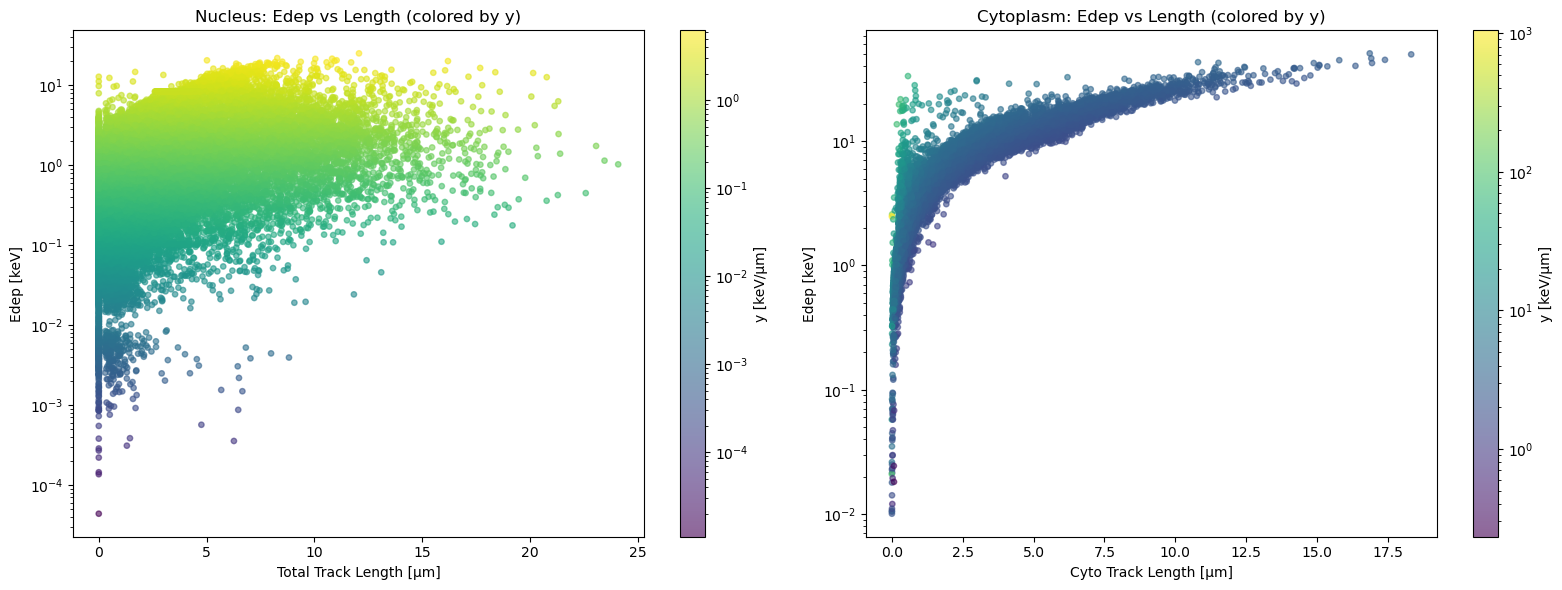

In [8]:
from matplotlib.colors import LogNorm

# --- Aggiunta: Analisi di Correlazione 2D Colorata ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlazione Nucleo
sc1 = axes[0].scatter(df['TotalTrackLength_um'], df['EdepNuc_keV'], 
                      c=df['yNuc_keV_um'], cmap='viridis', norm=LogNorm(), alpha=0.6, s=15)
axes[0].set_title('Nucleus: Edep vs Length (colored by y)')
axes[0].set_xlabel('Total Track Length [µm]')
axes[0].set_ylabel('Edep [keV]')
axes[0].set_yscale('log')
plt.colorbar(sc1, ax=axes[0], label='y [keV/µm]')

# Correlazione Citoplasma
sc2 = axes[1].scatter(df['CytoTrackLength_um'], df['EdepCyto_keV'], 
                      c=df['yCyto_keV_um'], cmap='viridis', norm=LogNorm(), alpha=0.6, s=15)
axes[1].set_title('Cytoplasm: Edep vs Length (colored by y)')
axes[1].set_xlabel('Cyto Track Length [µm]')
axes[1].set_ylabel('Edep [keV]')
axes[1].set_yscale('log')
plt.colorbar(sc2, ax=axes[1], label='y [keV/µm]')

plt.tight_layout()
plt.show()

Bilancio Energetico:
Nucleo: 60.14%
Citoplasma: 39.86%


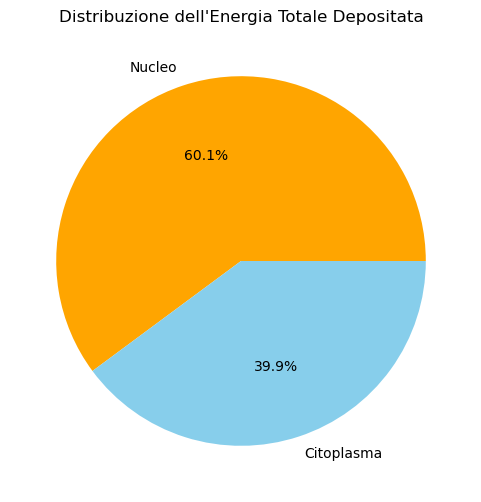

In [9]:
total_nuc = df['EdepNuc_keV'].sum()
total_cyto = df['EdepCyto_keV'].sum()
total_energy = total_nuc + total_cyto

# Calcolo percentuali
perc_nuc = (total_nuc / total_energy) * 100
perc_cyto = (total_cyto / total_energy) * 100

print(f"Bilancio Energetico:")
print(f"Nucleo: {perc_nuc:.2f}%")
print(f"Citoplasma: {perc_cyto:.2f}%")

# Plot
plt.figure(figsize=(6, 6))
plt.pie([perc_nuc, perc_cyto], labels=['Nucleo', 'Citoplasma'], autopct='%1.1f%%', colors=['orange', 'skyblue'])
plt.title('Distribuzione dell\'Energia Totale Depositata')
plt.show()

In [10]:
high_eff_mask = df['LET_Nuc'] > 5
n_high_eff = high_eff_mask.sum()
total_events = len(df)

print(f"Eventi ad alta efficacia biologica (LET > 5 keV/µm): {n_high_eff} su {total_events} ({ (n_high_eff/total_events)*100:.1f}%)")

Eventi ad alta efficacia biologica (LET > 5 keV/µm): 15569 su 100000 (15.6%)


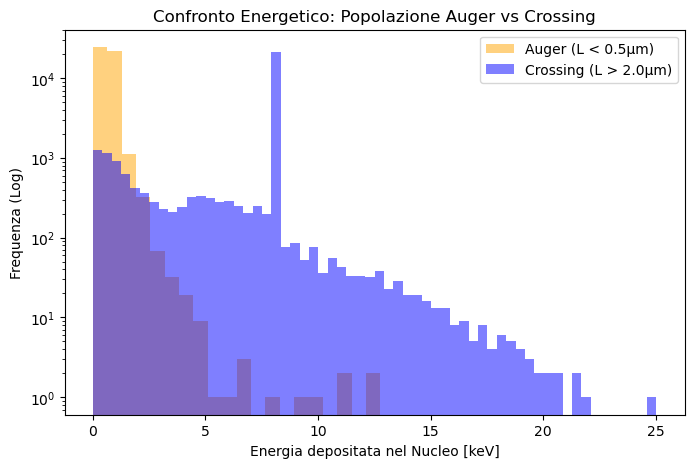

In [11]:
# Definizione soglia: < 0.5 um (Auger confinati), > 2.0 um (Attraversamenti lunghi)
auger_pop = df[df['NucTrackLength_um'] < 0.5]
cross_pop = df[df['NucTrackLength_um'] > 2.0]

plt.figure(figsize=(8, 5))
plt.hist(auger_pop['EdepNuc_keV'], bins=20, alpha=0.5, label='Auger (L < 0.5µm)', color='orange')
plt.hist(cross_pop['EdepNuc_keV'], bins=60, alpha=0.5, label='Crossing (L > 2.0µm)', color='blue')
plt.yscale('log')
plt.xlabel('Energia depositata nel Nucleo [keV]')
plt.ylabel('Frequenza (Log)')
plt.legend()
plt.title('Confronto Energetico: Popolazione Auger vs Crossing')
plt.show()

# Analisi Microdosimetrica di Elettroni Auger
### Discussione dei Risultati
- **Localizzazione (A):** La prevalenza della deposizione energetica nel nucleo (rispetto al citoplasma) conferma che la sorgente Auger produce un danno altamente localizzato, riducendo lo "spreco" energetico extranucleare.
- **Efficacia Biologica (B):** La frazione significativa di eventi ad alto LET (> 5 keV/µm) identifica la componente di elettroni Auger come primaria responsabile di *double-strand breaks* (DSB, che rappresenta il caso in cui la cellula esaurisce la sua capacità di riparazione fedele) nel DNA.
- **Validazione del Modello (C):** La netta distinzione tra le popolazioni 'Auger' (confinate) e 'Crossing' (attraversamenti) convalida la precisione geometrica della simulazione, dimostrando che il modello distingue correttamente tra radiazione a corto range e particelle a energia superiore.